# Processing Vietnamese Text
> Sources: [Vietnamese Online News Dataset](https://www.kaggle.com/datasets/haitranquangofficial/vietnamese-online-news-dataset)

Online articles from 25 most popular news sites in Vietnam in July 2022, suitable for practicing Natural Language Processing in Vietnamese.
Online news outlets are an unavoidable part of our society today due to its easy access, mostly-free. Their effects on the way community think and act are becoming a concern for a multitude groups of people, including legislators, content creators or marketers, just to name a few. Aside from the effects, what are being written on the news should be a good reflection of people’s will, attention and even cultural standard.
In Vietnam, even though journalists have received a lot of criticisms, especially in recent years, news outlets still receive a large amount of traffic (27%) compared to other methods to receive information.
```python
Id: Primary key in database, only for identification.
Author: Name of a person/group of journalists who wrote the article.
Title: Title of the article.
Content: Text content of the article.
Picture Count: How many pictures are used in the article.
Topic: Main topic of the article.
URL: URL of the article.
Source: Source of the news - name of the news outlet.
Crawled At: When was the article crawled (usually very close to the time it was uploaded)
Processed: Can be ignored
```

# 0. Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read file json with pandas
import pandas as pd

df = pd.read_json('../data/news_dataset.json')
df.head(10)

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
0,218270,,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",3,0,docbao.vn,"Tên cướp tiệm vàng tại Huế là đại uý công an, ...",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang...,2022-08-01 09:09:22.817308
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",1,0,vtc.vn,"Bỏ qua mạng 5G, Nga tiến thẳng từ 4G lên 6G",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-t...,2022-08-01 09:09:21.181469
2,218268,Hồ Sỹ Anh,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,3,0,thanhnien.vn,Địa phương nào đứng đầu cả nước tổng điểm 3 mô...,Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-c...,2022-08-01 09:09:15.311901
3,218267,Ngọc Ánh,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,1,0,vnexpress,Người chết trong mưa lũ 'nghìn năm có một' ở M...,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-...,2022-08-01 09:09:02.211498
4,218266,HẢI YẾN - MINH LÝ,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,12,0,soha,"Hải Phòng: Hình ảnh xe ""điên"" gây tai nạn liên...",Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay...,2022-08-01 09:09:01.601170
5,218265,,"Chia sẻ trên Twitter, thị trưởng Hanover Belit...",2,0,tuoitre.vn,Đức có thể suy thoái kinh tế năm nay,Thế giới,https://tuoitre.vn/duc-co-the-suy-thoai-kinh-t...,2022-08-01 09:09:01.320653
6,218264,,"""Em vỡ òa trong hạnh phúc khi được xướng tên ở...",8,0,baoquocte,Những khoảnh khắc đẹp của Gia Hân khi đăng qua...,Giải trí,https://baoquocte.vn/nhung-khoanh-khac-dep-cua...,2022-08-01 09:08:57.167808
7,218263,Hoàng Yến/VOV.VN,,1,0,vov.vn,Lịch thi đấu vòng 11 V-League 2022: HAGL dễ th...,THỂ THAO,https://vov.vn/the-thao/lich-thi-dau-vong-11-v...,2022-08-01 09:08:51.092437
8,218262,T.G,Soi kèo nhà cái Liverpool vs Strasbourg. Nhận ...,3,0,thethaovanhoa,Soi kèo nhà cái Liverpool vs Strasbourg. Nhận ...,,https://thethaovanhoa.vn/du-doan-bong-da/soi-k...,2022-08-01 09:08:47.355309
9,218261,Đỗ Trung,Siêu sao Bồ Đào Nha được HLV Erik ten Hag bố t...,1,0,bongdaplus,"Bị thay sau hiệp 1, Ronaldo đùng đùng bỏ về sớm",Ngoại hạng Anh,https://bongdaplus.vn/ngoai-hang-anh/ronaldo-d...,2022-08-01 09:08:42.496092


# 1. EDA & Visualization
- Kich thuoc so lieu: tong record, dung luong, do dai trung binh
- Ty le bi nan o cac truong: Author, Topic, Source

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184539 entries, 0 to 184538
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             184539 non-null  int64         
 1   author         184539 non-null  object        
 2   content        184539 non-null  object        
 3   picture_count  184539 non-null  int64         
 4   processed      184539 non-null  int64         
 5   source         184534 non-null  object        
 6   title          184539 non-null  object        
 7   topic          184539 non-null  object        
 8   url            184539 non-null  object        
 9   crawled_at     184125 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 14.1+ MB


In [4]:
df.describe()

,id,picture_count,processed,crawled_at
count,184539.000000,184539.000000,184539.000000,184125
mean,107012.895475,2.186470,0.999160,2022-07-09 04:33:03.084349184
min,1.000000,0.000000,0.000000,2022-06-07 14:05:50.904322
25%,48661.500000,1.000000,1.000000,2022-06-28 06:52:21.815848960
50%,108134.000000,1.000000,1.000000,2022-07-09 07:43:26.400500992
75%,161855.500000,3.000000,1.000000,2022-07-21 06:05:54.246563072
max,218270.000000,74.000000,1.000000,2022-08-01 09:09:22.817308
std,63607.360703,3.011839,0.028969,NaN


- Co tong cong 184.539 item
- Cac item duoc crawl vao thang 7/6/2022 den ngay 1/8/2022

- Author

In [5]:
# author, content, picture_count, processed, source, title, topic, url, crawled_at
df_categories = df['author'].value_counts().reset_index(name='Count')

df_categories["percentage"] = df['author'].value_counts(normalize=True).values * 100
df_categories

,author,Count,percentage
0,,36740,19.909071
1,PV/VOV.VN,897,0.486076
2,Trường Thịnh,698,0.378240
3,PV,602,0.326218
4,Việt Hà,496,0.268778
...,...,...,...
23035,"TTXVN-Thứ tư, ngày 27/07/2022 07:48 GMT+7",1,0.000542
23036,"PV (t/h)-Thứ tư, ngày 27/07/2022 07:49 GMT+7",1,0.000542
23037,"PV-Thứ tư, ngày 27/07/2022 07:50 GMT+7",1,0.000542
23038,"Ban Thời sự-Thứ tư, ngày 27/07/2022 07:52 GMT+7",1,0.000542


- So item khong co tac gia la 36.740 row, chiem toi gan 20%

In [6]:
# Chuyen thanh Nan
df['author'] = df['author'].replace("", np.nan)

In [7]:
print((df == "").sum())

id                   0
author               0
content          23321
picture_count        0
processed            0
source               0
title               17
topic            39488
url                  0
crawled_at           0
dtype: int64


- Content va Topic van con gia tri trong "", se chuyen thanh Nan

In [8]:
df['content'] = df['content'].replace("", np.nan)
df['title'] = df['content'].replace("", np.nan)
df['topic'] = df['topic'].replace("", np.nan)

In [9]:
print((df == "").sum())

id               0
author           0
content          0
picture_count    0
processed        0
source           0
title            0
topic            0
url              0
crawled_at       0
dtype: int64


In [ ]:
# Tong quan du lieu
print("Tong record: ", len(df))
print("Gom cac truong: ", df.columns)
df.head()

Tong record:  184539
Gom cac truong:  Index(['id', 'author', 'content', 'picture_count', 'processed', 'source',
       'title', 'topic', 'url', 'crawled_at'],
      dtype='object')


,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
0,218270,NaN,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",3,0,docbao.vn,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang...,2022-08-01 09:09:22.817308
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",1,0,vtc.vn,"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-t...,2022-08-01 09:09:21.181469
2,218268,Hồ Sỹ Anh,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,3,0,thanhnien.vn,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-c...,2022-08-01 09:09:15.311901
3,218267,Ngọc Ánh,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,1,0,vnexpress,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-...,2022-08-01 09:09:02.211498
4,218266,HẢI YẾN - MINH LÝ,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,12,0,soha,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay...,2022-08-01 09:09:01.601170


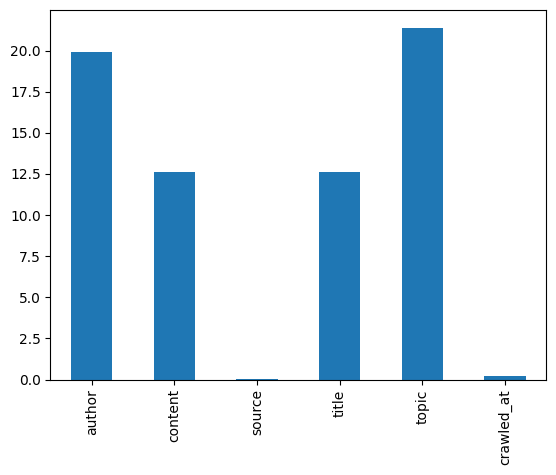

In [11]:
# Ty le bi nan 
def percent_na(df):
    nan_ratio = df.isna().mean() * 100
    nan_ratio = nan_ratio[nan_ratio > 0]
    nan_ratio.plot(kind="bar")
    plt.show()
percent_na(df)

- Nhieu so luong row bi Nan: nhieu nhat la topic, sau do la author, dac biet la content va tile co so luong Nan bang nhau

In [12]:
# Kiem tra content bi nan va title bi nan luon khong
nan_rows = df[df[['content', 'title']].isna().all(axis=1)]
nan_rows

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
7,218263,Hoàng Yến/VOV.VN,NaN,1,0,vov.vn,NaN,THỂ THAO,https://vov.vn/the-thao/lich-thi-dau-vong-11-v...,2022-08-01 09:08:51.092437
25,218245,NaN,NaN,0,0,vtv.vn,NaN,NaN,https://vtv.vn/video/sang-phuong-nam-01-8-2022...,2022-08-01 09:06:29.712298
30,218240,NaN,NaN,0,0,zingnews,NaN,NaN,https://zingnews.vn/video-tai-xe-gap-su-co-khi...,2022-08-01 09:05:55.279362
52,218218,NaN,NaN,0,0,dantri,NaN,NaN,https://dantri.com.vn/kinh-doanh/dang-sau-chuy...,2022-08-01 09:03:46.592619
54,218216,Nguyễn Ngọc,NaN,0,0,anninhthudo,NaN,Thế giới,https://www.anninhthudo.vn/ukraine-doc-toan-lu...,2022-08-01 09:03:27.744993
...,...,...,...,...,...,...,...,...,...,...
184509,30,Nhóm PV,NaN,6,1,zingnews,NaN,Pháp luật,https://zingnews.vn/cong-an-kham-xet-nha-ong-n...,2022-06-07 14:06:07.116748
184510,29,Quỳnh Danh - Lan Anh,NaN,14,1,zingnews,NaN,Kinh doanh,https://zingnews.vn/sieu-du-thuyen-150-trieu-u...,2022-06-07 14:06:06.595337
184511,28,Hải Nam - Hoàng Lam,NaN,8,1,zingnews,NaN,Pháp luật,https://zingnews.vn/cong-an-kiem-sat-vien-xuat...,2022-06-07 14:06:06.098968
184512,27,Song Nguyên,NaN,8,1,zingnews,NaN,Du lịch,https://zingnews.vn/ben-trong-sieu-du-thuyen-c...,2022-06-07 14:06:05.597046


In [13]:
condition = df['content'].isna() & df['title'].notna()
filtered_df = df[condition]
filtered_df

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at


- Da so cac cot content bi nan thi title se bi nan theo
-> Bo cac cot nay boi khong co chu de hay text de phan tich

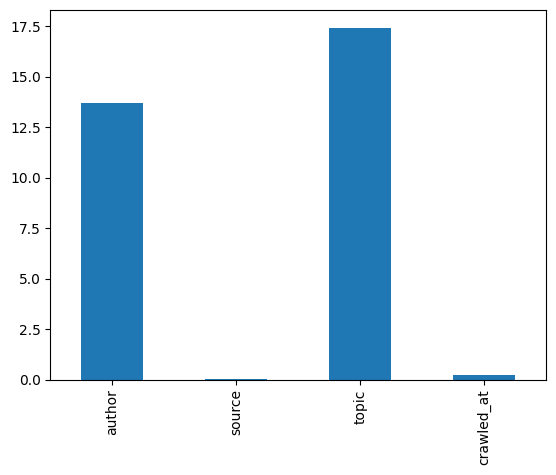

In [14]:
df = df.dropna(subset='content')
percent_na(df)

In [15]:
df[df['source'].isna()]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
80680,119985,Minh Phương,Tàu chiến Nga phóng tên lửa từ Biển Đen nhằm v...,2,1,None,Tàu chiến Nga phóng tên lửa từ Biển Đen nhằm v...,"['Thế giới', 'Quân sự']",https://dantri.com.vn/the-gioi/50-ten-lua-nga-...,2022-07-13 09:12:57.087074
137000,50466,Thiên Bình,Pau FC được thành lập từ năm 1920 nhưng chính ...,2,1,None,Pau FC được thành lập từ năm 1920 nhưng chính ...,Thể thao,https://vietnamnet.vn/pau-fc-clb-phap-ma-quang...,2022-06-28 10:36:51.877089
137007,50459,Đại Nam,"Trên trang cá nhân của mình, người đại diện dẫ...",1,1,None,"Trên trang cá nhân của mình, người đại diện dẫ...",Thể thao,https://vietnamnet.vn/quang-hai-day-la-chuyen-...,2022-06-28 10:34:21.832790
137122,50338,Trần Chung,Nhu cầu lưu trú và ăn uống tăng mạnh Những ngà...,2,1,None,Nhu cầu lưu trú và ăn uống tăng mạnh Những ngà...,Kinh Doanh,https://vietnamnet.vn/vua-phuc-hoi-bao-gia-qua...,2022-06-28 10:12:15.446931


- Chi co 3 bai khong co source. Tuy nhien, van co the dung url de them vao

| url | source |
| --- | --- |
| https://dantri.com.vn/ | dantri |
| https://vietnamnet.vn/ | vietnamnet.vn |
  

In [16]:
df.loc[df['id']==119985, 'source'] = 'dantri' 
df.loc[(df['id']==50466) | (df['id']==50459) | (df['id']==50338), 'source'] = 'vietnamnet.vn'
df[df['source'].isna()]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at


In [17]:
df[df['crawled_at'].isna()]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
183641,898,Ngọc Thạch-Tuấn Nguyễn/VOV-Cairo,"Ngày 8/6, đoàn công tác Đại sứ quán Việt Nam t...",3,1,vov.vn,"Ngày 8/6, đoàn công tác Đại sứ quán Việt Nam t...",NGƯỜI VIỆT,https://vov.vn/nguoi-viet/thuc-day-hop-tac-kin...,NaT
183643,896,CTV Vũ Tuyến/VOV.VN\nTheo Aconsciousrethink,1. Dành thời gian cho bản thân nhiều hơn Ai cũ...,2,1,vov.vn,1. Dành thời gian cho bản thân nhiều hơn Ai cũ...,ĐỜI SỐNG,https://vov.vn/doi-song/tinh-yeu-gia-dinh/de-k...,NaT
183650,889,CTV Kiến An/VOV.VN (biên dịch)\nTheo 9to5Mac,Lưu ý rằng iOS 16 hiện có sẵn dưới dạng beta d...,3,1,vov.vn,Lưu ý rằng iOS 16 hiện có sẵn dưới dạng beta d...,CÔNG NGHỆ,https://vov.vn/cong-nghe/trai-nghiem/tim-hieu-...,NaT
183652,887,CTV Thanh Huyền/VOV.VN,"Mang sứ mệnh “thăng hoa giá trị sống”, Su...",3,1,vov.vn,"Mang sứ mệnh “thăng hoa giá trị sống”, Su...",Doanh nghiệp,https://vov.vn/doanh-nghiep/doanh-nghiep-24h/s...,NaT
183653,886,CTV Nguyễn Hà/VOV.VN,"Những dự án sắp bàn giao, thanh khoản tốt và c...",5,1,vov.vn,"Những dự án sắp bàn giao, thanh khoản tốt và c...",Doanh nghiệp,https://vov.vn/doanh-nghiep/doanh-nghiep-24h/t...,NaT
...,...,...,...,...,...,...,...,...,...,...
184502,37,Minh Châu,Mỗi người đều có trong mình những ký ức tươi đ...,3,1,zingnews,Mỗi người đều có trong mình những ký ức tươi đ...,Xuất bản,https://zingnews.vn/nhung-mon-ngon-dam-hon-que...,NaT
184505,34,Alex Ferguson / NXB Trẻ,Trong lần đầu tiên dẫn dắt Arsenal thi đấu với...,1,1,zingnews,Trong lần đầu tiên dẫn dắt Arsenal thi đấu với...,Xuất bản,https://zingnews.vn/cuoc-doi-dau-khong-khoan-n...,NaT
184506,33,Thu Huệ,James Daunt - Giám đốc điều hành chuỗi nhà sác...,1,1,zingnews,James Daunt - Giám đốc điều hành chuỗi nhà sác...,Xuất bản,https://zingnews.vn/cac-hieu-sach-o-thanh-pho-...,NaT
184517,22,Xuân Sang,"Theo dữ liệu từ TradingView, Bitcoin kết thúc ...",1,1,zingnews,"Theo dữ liệu từ TradingView, Bitcoin kết thúc ...",Công nghệ,https://zingnews.vn/ky-luc-buon-cua-bitcoin-ch...,NaT


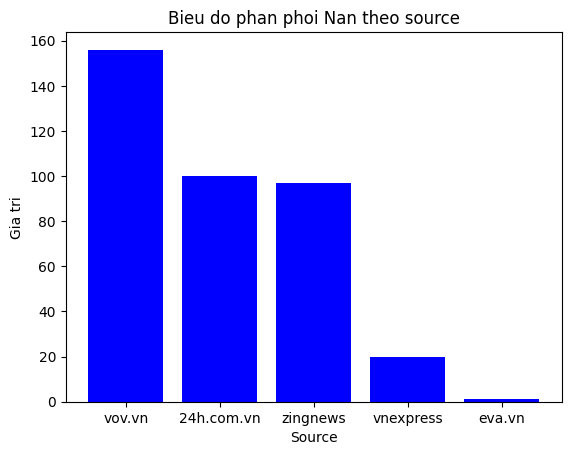

In [18]:
source_nan = df[df['crawled_at'].isna()]['source'].value_counts()
plt.bar(source_nan.index, source_nan.values, color='blue')
plt.title('Bieu do phan phoi Nan theo source')
plt.xlabel('Source')
plt.ylabel('Gia tri')
plt.show()

Trong gia tri bi Nan, da phan la den tu nguon la vov sau do la 24h. Tuy nhien, khong anh huong len den viec phan tich, nen minh bo qua phan xu ly cho thoi gian crawl

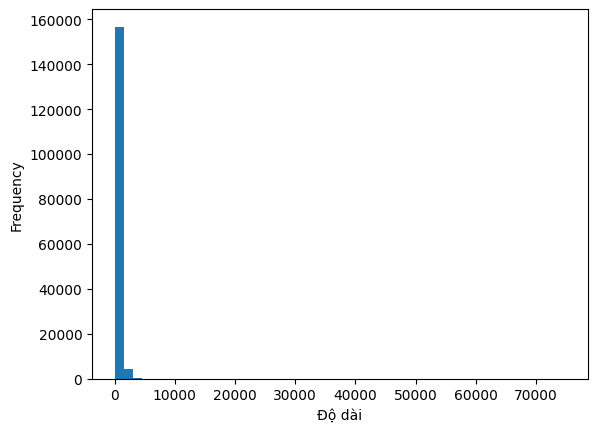

In [19]:
# Xem do dai van ban
content_col = df['content']
content_len = content_col.apply(lambda x: len(x.split()) if type(x) == str else 0)
content_len.plot(kind="hist", bins=50)
plt.xlabel("Độ dài")
plt.show()

In [20]:
df['content_len'] = df['content'].str.len()
df[df['content_len'] == 0]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at,content_len


Da so, so luong ky tu trong content nho hon 50.000 ky tu -> co nhung ngoai le o sau do

In [21]:
pd.set_option("display.max_rows", None)

In [22]:
# print nhung row co content len hon 10.000 ky tu
df[df['content_len']> 10000]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at,content_len
904,217113,Hường Cao,Cơm chiên trứng hay còn được gọi với cái tên d...,0,1,eva.vn,Cơm chiên trứng hay còn được gọi với cái tên d...,Món ngon cuối tuần,https://eva.vn/mon-ngon-cuoi-tuan/9-cach-lam-c...,2022-07-31 23:28:38.446197,12727
1443,216454,K.T,"Bất thường vụ nữ sinh ""có nồng độ cồn cao"" bị ...",0,1,eva.vn,"Bất thường vụ nữ sinh ""có nồng độ cồn cao"" bị ...",Tin tức,https://eva.vn/tin-tuc/tin-tuc-24h-bat-thuong-...,2022-07-31 20:05:12.027718,10684
1550,216328,Bích Ngọc,"Diễn viên trẻ than thở không đủ tiền để ""chơi ...",8,1,dantri,"Diễn viên trẻ than thở không đủ tiền để ""chơi ...",Văn hóa,https://dantri.com.vn/van-hoa/nhung-sao-bi-pha...,2022-07-31 19:30:04.753085,13152
2243,215520,NaN,"Trước đó, Thủ tướng đã có buổi đối thoại trực ...",0,1,baochinhphu,"Trước đó, Thủ tướng đã có buổi đối thoại trực ...",Cổng TTĐT Chính phủ,https://baochinhphu.vn/thu-tuong-chinh-phu-doi...,2022-07-31 15:39:10.861828,13097
2566,215137,Lạc Xuân,* Xin chào diễn viên Minh Dự! Được biết sắp tớ...,7,1,thanhnien.vn,* Xin chào diễn viên Minh Dự! Được biết sắp tớ...,Giải trí,https://thanhnien.vn/minh-du-khong-the-do-thua...,2022-07-31 13:47:15.875092,12716
2581,215117,Lan Anh,"Chiều 30/7, Thủ tướng Phạm Minh Chính chủ trì ...",2,1,vietnamnet.vn,"Chiều 30/7, Thủ tướng Phạm Minh Chính chủ trì ...",Tuần Việt Nam,https://vietnamnet.vn/kien-dinh-kiem-soat-lam-...,2022-07-31 13:43:36.257588,10885
2701,214985,"Toàn cảnh thế giới-Chủ nhật, ngày 31/07/2022 1...",Đang giữa mùa hè nắng đổ lửa mà người dân châu...,9,1,vtv.vn,Đang giữa mùa hè nắng đổ lửa mà người dân châu...,NaN,https://vtv.vn/the-gioi/mua-dong-thieu-hoi-am-...,2022-07-31 13:11:50.530852,11939
3183,214440,PGS.TS NGUYỄN THANH TUẤN,"Cho đến nay, Quốc hội và các cơ quan có thẩm q...",1,1,baoquocte,"Cho đến nay, Quốc hội và các cơ quan có thẩm q...",Góc nhìn nhân quyền,https://baoquocte.vn/phap-luat-phap-che-phap-q...,2022-07-31 10:45:50.455051,10181
3879,213538,Theo Lan Anh (Theo Themysteriousworld) (Arttimes),Pháp luôn được xem là một điểm đến lãng mạn vớ...,19,1,24h.com.vn,Pháp luôn được xem là một điểm đến lãng mạn vớ...,Du lịch,https://www.24h.com.vn/du-lich-24h/9-diem-du-l...,2022-07-31 03:25:32.929714,10315
3965,213417,Nguyễn Thành Tô,"Công ước về quyền trẻ em năm 1989 ghi nhận: ""N...",2,1,zingnews,"Công ước về quyền trẻ em năm 1989 ghi nhận: ""N...",Pháp luật,https://zingnews.vn/lam-dung-tinh-duc-tre-em-q...,2022-07-31 02:13:08.210569,11353


co 11 hang co so luong ky tu lon. Tuy nhien, nhung noi dung o content rat huu ich chu khong phai spam.

-> Khong bo cac hang ngoai le nay

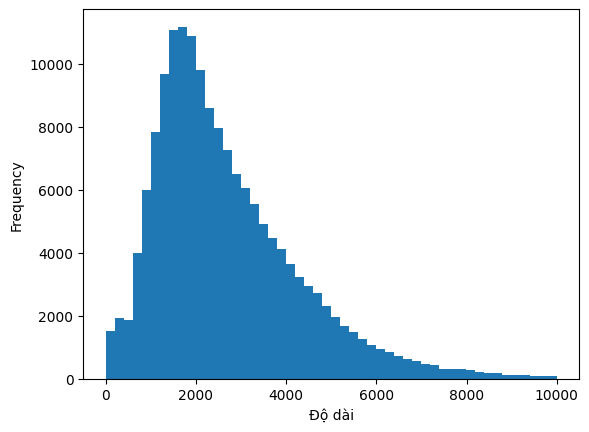

In [23]:
# Phan phoi do dai tu 0 den 10.000
# Xem do dai van ban
df[df['content_len'] <= 10000]['content_len'].plot(kind="hist", bins=50)
plt.xlabel("Độ dài")
plt.show()

So ky tu lon nhat la 2000 ky tu, sau do so luong content dai giam dan

-> phan phoi kha giong phan phoi chuan, nhung da dang so luong content co ky tu dai hon 2.000.

In [24]:
pd.set_option('display.max_rows', 20)

In [25]:
df[df['topic'].isna()]

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at,content_len
8,218262,T.G,Soi kèo nhà cái Liverpool vs Strasbourg. Nhận ...,3,0,thethaovanhoa,Soi kèo nhà cái Liverpool vs Strasbourg. Nhận ...,NaN,https://thethaovanhoa.vn/du-doan-bong-da/soi-k...,2022-08-01 09:08:47.355309,1771
10,218260,Lan Đỗ - Thu Ngân,Nỗi lo nhà cửa xuống cấp chậm được sửa chữa ch...,0,0,danviet,Nỗi lo nhà cửa xuống cấp chậm được sửa chữa ch...,NaN,https://danviet.vn/ha-noi-nguoi-lao-dong-than-...,2022-08-01 09:08:36.582269,368
12,218258,Bảo Hà,Ai Cập đã hủy đơn đặt hàng 240.000 tấn lúa mì ...,0,0,soha,Ai Cập đã hủy đơn đặt hàng 240.000 tấn lúa mì ...,NaN,https://soha.vn/ukraine-mat-khach-hang-lon-mua...,2022-08-01 09:08:30.261355,1969
16,218254,Hoàng Kim,"Cuối tuần qua, Đài Truyền hình TP.HCM đã tổ ch...",3,0,thethaovanhoa,"Cuối tuần qua, Đài Truyền hình TP.HCM đã tổ ch...",NaN,https://thethaovanhoa.vn/van-hoa/chuong-vang-v...,2022-08-01 09:08:13.106296,5444
19,218251,NaN,"Ngày 1/8, ông Nguyễn Hữu Ngạn, Chủ tịch UBND x...",0,0,zingnews,"Ngày 1/8, ông Nguyễn Hữu Ngạn, Chủ tịch UBND x...",NaN,https://zingnews.vn/xac-dinh-danh-tinh-nguoi-p...,2022-08-01 09:07:35.070134,1663
...,...,...,...,...,...,...,...,...,...,...,...
183357,1183,Nguyễn Tú,"Trước đó, qua trinh sát đấu tranh chống buôn l...",2,1,thanhnien.vn,"Trước đó, qua trinh sát đấu tranh chống buôn l...",NaN,https://thanhnien.vn/da-nang-cong-an-mat-1-nga...,2022-06-10 09:38:48.783718,1144
183358,1182,Thụy Miên,"Hôm qua, Cơ quan Y tế quốc gia EODY của Hy Lạp...",1,1,thanhnien.vn,"Hôm qua, Cơ quan Y tế quốc gia EODY của Hy Lạp...",NaN,https://thanhnien.vn/dau-mua-khi-tiep-tuc-lay-...,2022-06-10 09:38:48.342010,3157
183787,752,Theo Như Nguyễn (Dân Việt)\n.,"Do đó, tìm hiểu kiến thức cơ bản về đầu tư cổ ...",2,1,24h.com.vn,"Do đó, tìm hiểu kiến thức cơ bản về đầu tư cổ ...",NaN,https://www.24h.com.vn/kinh-doanh/choi-chung-k...,2022-06-09 07:32:17.382406,5670
184402,137,Thúy Hà,"Ngày 7/4, kênh Grazy Grace phát hành video phỏ...",1,1,zingnews,"Ngày 7/4, kênh Grazy Grace phát hành video phỏ...",NaN,https://zingnews.vn/nhom-nhac-bi-quay-roi-tinh...,NaT,1880


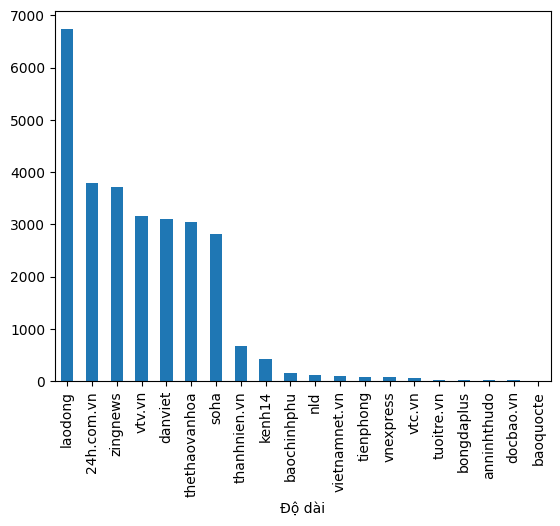

In [26]:
df[df['topic'].isna()]['source'].value_counts().plot(kind="bar")
plt.xlabel("Độ dài")
plt.show()

- Bao "lao dong" thieu nhieu nhieu topic nhat

Chung cho tat ca cac field la loai

C:\Users\mt200\AppData\Local\Temp\ipykernel_25784\2375089771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mt200\AppData\Local\Temp\ipykernel_25784\2375089771.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mt200\AppData\Local\Temp\ipykernel_25784\2375089771.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


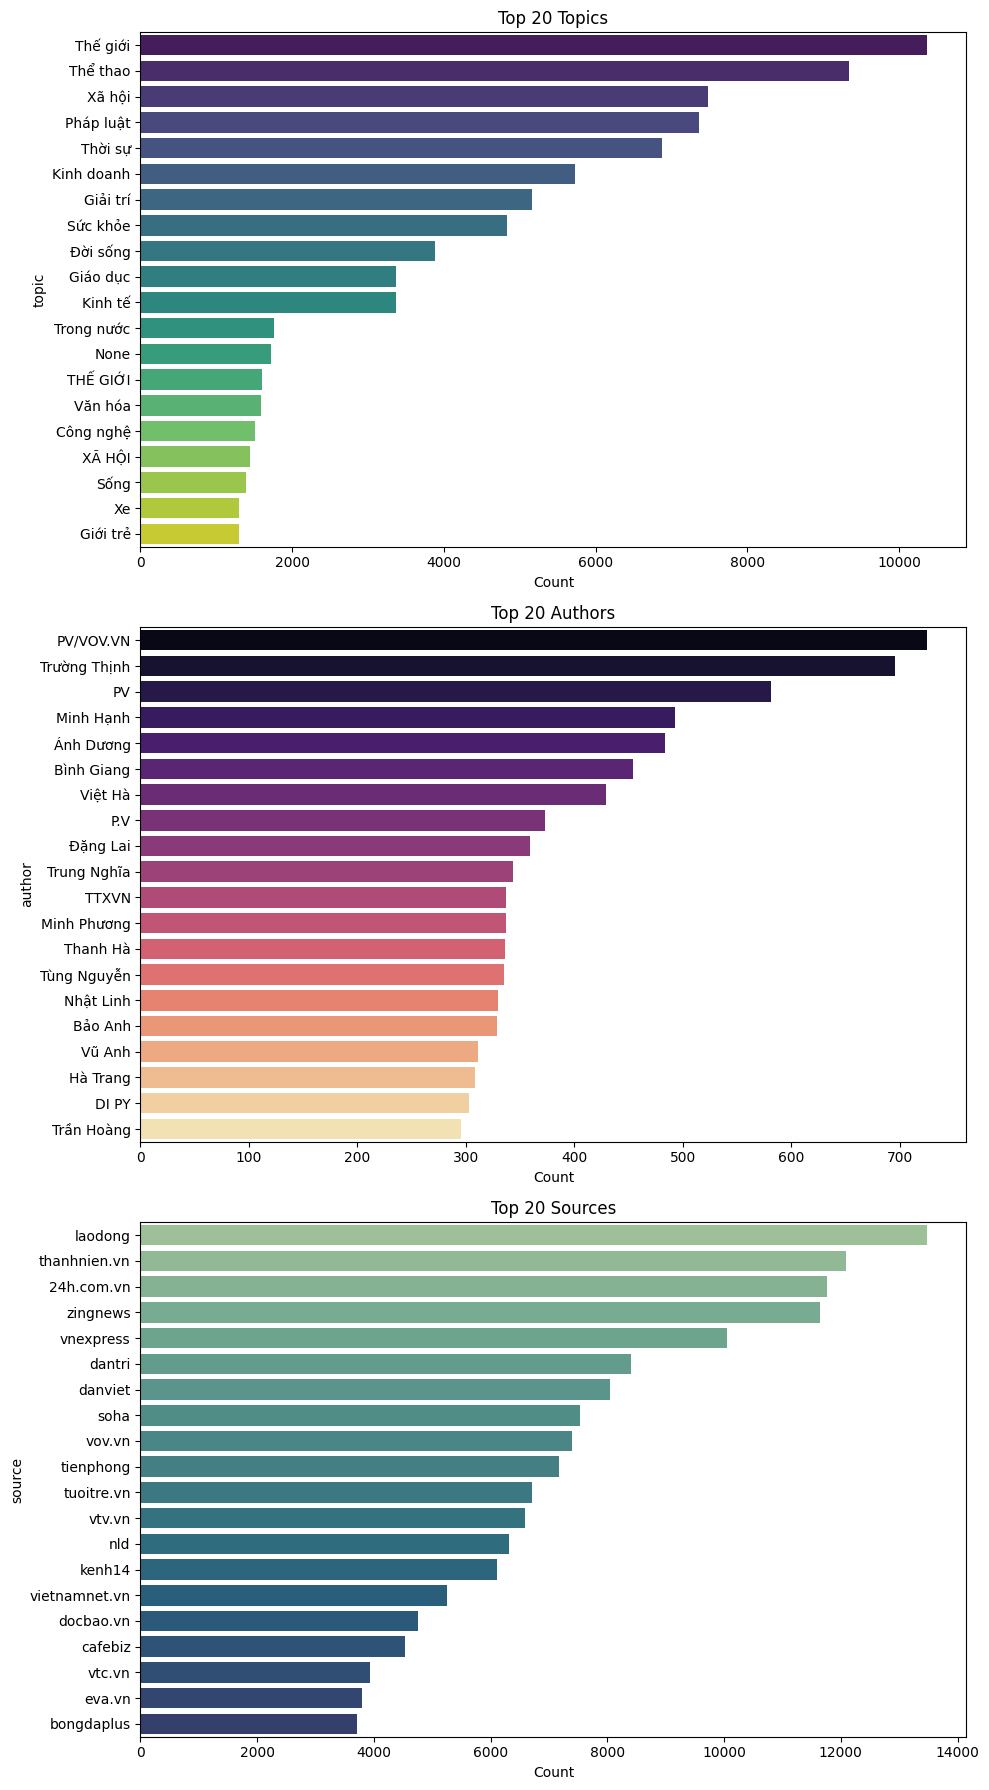

In [27]:
import seaborn as sns

# Plot top 20 bar charts
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

sns.barplot(
    x=df["topic"].value_counts().head(20).values,
    y=df["topic"].value_counts().head(20).index,
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 20 Topics")
axes[0].set_xlabel("Count")

sns.barplot(
    x=df["author"].value_counts().head(20).values,
    y=df["author"].value_counts().head(20).index,
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Top 20 Authors")
axes[1].set_xlabel("Count")

sns.barplot(
    x=df["source"].value_counts().head(20).values,
    y=df["source"].value_counts().head(20).index,
    ax=axes[2],
    palette="crest",
)
axes[2].set_title("Top 20 Sources")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

[]

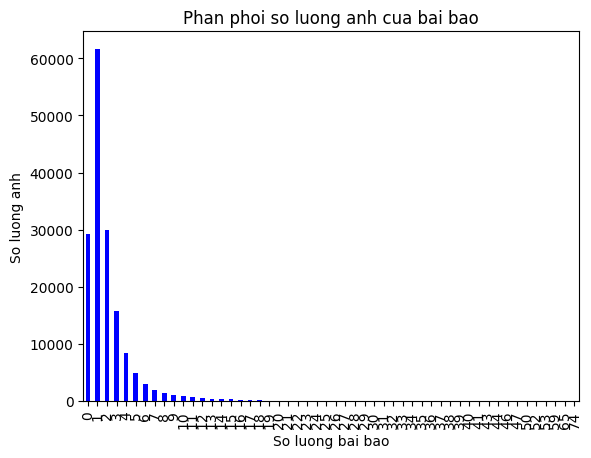

In [28]:
df["picture_count"].value_counts().sort_index().plot(kind="bar", color="blue")
plt.title("Phan phoi so luong anh cua bai bao")
plt.xlabel("So luong bai bao")
plt.ylabel("So luong anh")
plt.plot()

In [29]:
df[df['picture_count'] > 20].sort_values(by='picture_count', ascending=False)

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at,content_len
165962,20188,"Minh Huyền,","Trải qua nhiều thập kỷ, dòng phim cổ trang vẫn...",74,1,kenh14,"Trải qua nhiều thập kỷ, dòng phim cổ trang vẫn...",Star,https://kenh14.vn/tu-dai-my-nhan-co-trang-luu-...,2022-06-20 00:11:01.436895,8454
89727,110749,Minh Thắng,* NHẬN ĐỊNH Tranh cãi đã nổ ra sau khi Rafael ...,65,1,thanhnien.vn,* NHẬN ĐỊNH Tranh cãi đã nổ ra sau khi Rafael ...,Thể thao,https://thanhnien.vn/chung-ket-wimbledon-2022-...,2022-07-10 06:31:48.432510,2699
93476,106785,"ĐÀO ANH TÚ,","Nhắc đến điện ảnh Hàn Quốc, một trong những đi...",59,1,kenh14,"Nhắc đến điện ảnh Hàn Quốc, một trong những đi...",Series Truyền Hình,https://kenh14.vn/nhan-sac-seo-ye-ji-suzy-seoh...,2022-07-08 16:42:05.324870,6909
130906,57185,KHÁNH VY - THIẾT KẾ: MAI LINH,"Vừa qua, show truyền hình thực tế ""2 ngày 1 đê...",53,1,soha,"Vừa qua, show truyền hình thực tế ""2 ngày 1 đê...",NaN,https://soha.vn/khong-chi-co-phu-quoc-kien-gia...,2022-06-29 17:35:33.766599,7163
99551,100155,Thanh Niên,Hà Nội là địa phương có số thí sinh dự thi lớn...,52,1,thanhnien.vn,Hà Nội là địa phương có số thí sinh dự thi lớn...,Giáo dục,https://thanhnien.vn/hon-1-trieu-thi-sinh-buoc...,2022-07-07 06:06:06.358662,1988
...,...,...,...,...,...,...,...,...,...,...,...
146946,39828,Quốc Minh,"Sáng 25/6, ông Đặng Lê Nguyên Vũ trưng bày dàn...",21,1,soha,"Sáng 25/6, ông Đặng Lê Nguyên Vũ trưng bày dàn...",Kinh doanh,https://soha.vn/dan-xe-hon-100-ty-dong-cua-ong...,2022-06-25 16:24:30.831770,2766
2403,215329,NHƯ TRÚC,MasterChef được đến biết là 1 chương trình thự...,21,1,soha,MasterChef được đến biết là 1 chương trình thự...,NaN,https://soha.vn/khi-mon-an-viet-len-song-maste...,2022-07-31 14:43:58.973038,4167
1834,216007,"Duy Nam,",Nối tiếp chuỗi sự kiện đậm chất mùa hè miền nh...,21,1,kenh14,Nối tiếp chuỗi sự kiện đậm chất mùa hè miền nh...,Star Style,https://kenh14.vn/hoa-hau-thuy-tien-hoa-nu-tha...,2022-07-31 17:57:28.075107,1398
183285,1255,Hoa Nữ,Mát xa cho hoa hồng Tốt nghiệp ngành công nghệ...,21,1,thanhnien.vn,Mát xa cho hoa hồng Tốt nghiệp ngành công nghệ...,NaN,https://thanhnien.vn/nang-hong-kiem-nhieu-tien...,2022-06-10 09:39:23.753830,5539


# 2. Preprocessing
- Text preprocessing (normalization, tokenization, stopwords, lemmatization, vectorization)
  - Norm: lower_case
  - Tokenization
- Comparison


In [30]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
pip install pyvi -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import unicodedata
import nltk, re, pprint
from pyvi import ViTokenizer # Tokenize tieng Viet

In [33]:
df = df.copy()
df.drop(columns=["processed"], inplace=True)

In [34]:
# Thống nhất các trường dữ liệu
df['author'] = df["author"].fillna("Unknown").astype("string")
df['content'] = df["content"].astype("string") # da xu ly nen khong can
df["source"] = df["source"].fillna("Unknown").astype("string")
df["title"] = df["title"].astype("string") # da xu ly nen khong can
df["topic"] = df["topic"].fillna("Unknown").astype("string")
df["url"] = df["url"].fillna("Unknown").astype("string")
df["crawled_at"] = pd.to_datetime(df["crawled_at"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161218 entries, 0 to 184538
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             161218 non-null  int64         
 1   author         161218 non-null  string        
 2   content        161218 non-null  string        
 3   picture_count  161218 non-null  int64         
 4   source         161218 non-null  string        
 5   title          161218 non-null  string        
 6   topic          161218 non-null  string        
 7   url            161218 non-null  string        
 8   crawled_at     160844 non-null  datetime64[ns]
 9   content_len    161218 non-null  int64         
dtypes: datetime64[ns](1), int64(3), string(6)
memory usage: 13.5 MB


In [35]:
# So luong con lai sau khi tien xu ly
df.describe()

,id,picture_count,crawled_at,content_len
count,161218.000000,161218.000000,160844,161218.000000
mean,106881.393300,2.081089,2022-07-09 03:45:19.048813568,2730.681233
min,1.000000,0.000000,2022-06-07 14:05:50.904322,1.000000
25%,48415.250000,1.000000,2022-06-28 06:07:02.309486592,1537.000000
50%,107902.500000,1.000000,2022-07-09 06:36:08.382469120,2311.000000
75%,161875.750000,3.000000,2022-07-21 06:07:31.250060800,3526.000000
max,218270.000000,74.000000,2022-08-01 09:09:22.817308,334634.000000
std,63704.273085,2.673157,NaN,1984.457534


In [36]:
import string
import regex as re 

# Normalize: chuyen ve chu thuong, chuan hoa, loai bo dau cau, khoang trang thua
def clean_and_normalize(txt):
    if not isinstance(txt, str):
        return ""
    # Chuyen ve chu thuong
    txt = txt.lower()
    # Chuan hoa Unicode (NFC)
    txt = unicodedata.normalize("NFC", txt)
    # Loai bo so
    txt = re.sub(r'\d+', '', txt)
    # Loại bỏ dấu câu (punctuation) và khoảng trắng thừa
    # Thay thế dấu câu bằng khoảng trắng để tránh dính từ
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    txt = txt.translate(translator)
    # Loại bỏ khoảng trắng thừa (ví dụ: "  " thành " ")
    txt = " ".join(txt.split())
    return txt

In [37]:
# # 2. Ham xu ly tong the (Chuan hoa & Tokenize )
# def pipeline_processing(txt):
#     cleaned_txt = clean_and_normalize(txt)
#     # Tach tu tieng Viet
#     tokenized_txt = ViTokenizer.tokenize(cleaned_txt)
#     return tokenized_txt

# # 3. Ap dung cac ham
# df['content_token'] = df['content'].apply(pipeline_processing)
# df['title_token'] = df['title'].apply(pipeline_processing)

In [38]:
# tokenization - doi kha lau
# df['content_token'] = df['content'].apply(lambda x : ViTokenizer.tokenize(x))
# df['title_token'] = df['title'].apply(lambda x : ViTokenizer.tokenize(x))

In [39]:
df

,id,author,content,picture_count,source,title,topic,url,crawled_at,content_len
0,218270,Unknown,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",3,docbao.vn,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang...,2022-08-01 09:09:22.817308,2762
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",1,vtc.vn,"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-t...,2022-08-01 09:09:21.181469,1443
2,218268,Hồ Sỹ Anh,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,3,thanhnien.vn,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-c...,2022-08-01 09:09:15.311901,5664
3,218267,Ngọc Ánh,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,1,vnexpress,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-...,2022-08-01 09:09:02.211498,1457
4,218266,HẢI YẾN - MINH LÝ,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,12,soha,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay...,2022-08-01 09:09:01.601170,1117
...,...,...,...,...,...,...,...,...,...,...
184534,5,Quốc Thắng,"Chiều 7/6, Khoa bị Công an quận Phú Nhuận phối...",2,vnexpress,"Chiều 7/6, Khoa bị Công an quận Phú Nhuận phối...",Pháp luật,https://vnexpress.net/nghi-can-sat-hai-cha-bi-...,2022-06-07 14:05:53.848085,1033
184535,4,Thảo Mi,"Ngày 7/6, phiên xử phúc thẩm ông Tất Thành Can...",2,vnexpress,"Ngày 7/6, phiên xử phúc thẩm ông Tất Thành Can...",Pháp luật,https://vnexpress.net/ong-tat-thanh-cang-duoc-...,2022-06-07 14:05:53.482540,5655
184536,3,Thanh Tâm,"""Các khu dân cư của thành phố Severodonetsk đã...",2,vnexpress,"""Các khu dân cư của thành phố Severodonetsk đã...",Thế giới,https://vnexpress.net/nga-tuyen-bo-giai-phong-...,2022-06-07 14:05:51.797545,1936
184537,2,Lâm Thỏa,"*Việt Nam - Malaysia: 20h thứ Tư 8/6, trên VnE...",2,vnexpress,"*Việt Nam - Malaysia: 20h thứ Tư 8/6, trên VnE...",Thể thao,https://vnexpress.net/hlv-malaysia-doa-ngang-d...,2022-06-07 14:05:51.433712,2281


Tieng Viet khong co dang bien the cua tu nhu Tieng Anh (shoe -> shoes, go -> went), nen se khong su dung stemming lemma hoac

In [40]:
import os

# remove stopword
def load_stopwords_from_txt(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        words = [line.strip().lower().replace("_", " ") for line in f if line.strip()]
    return set(words)

stopwords = load_stopwords_from_txt("../data/vietnamese-stopwords-dash.txt")


In [41]:
# Test with spacy
!pip install spacy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\mt200\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [42]:
import sys
!{sys.executable} -m pip install spacy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import spacy
print(spacy.__version__)

3.8.15


In [44]:
from collections import Counter
nlp = spacy.blank("vi") 

def process_with_spacy(text):
    if not isinstance(text, str):
        return []
    doc = nlp(clean_and_normalize(text))
    cleaned_tokens = [token.text for token in doc if token.text not in stopwords]
    return cleaned_tokens


In [ ]:
df['content_spacy_token'] = df['content'].apply(process_with_spacy)
print('---------------------------------------------')
df['title_spacy_token'] = df['title'].apply(process_with_spacy)

In [ ]:
df

In [ ]:
pip install wordcloud

In [ ]:
all_tokens = [
    token 
    for column in ['content_spacy_token', 'title_spacy_token']
    for token_list in df[column].dropna()
    for token in token_list
]
token_counts = Counter(all_tokens)
count_vietnamese_tokens = dict(token_counts.most_common(50))

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wc = WordCloud(
    width=1600,
    height=900,
    background_color="#0f172a",
    colormap="Spectral",
    max_words=50,
    contour_width=3,
    contour_color="#38bdf8",
).generate_from_frequencies(count_vietnamese_tokens)

# Render and save the high-resolution image
plt.figure(figsize=(16, 9), facecolor="#0f172a")
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig(
    "top_vietnamese_tokens.png", facecolor="#0f172a", bbox_inches="tight"
)
plt.show()

# Apply 4 techniques

In [ ]:
# Gop cac token lai
df['content_clean'] = df['content_spacy_token'].apply(lambda x: ''.join(x) if isinstance(x, list) else '')
df['title_clean'] = df['title_clean'].apply(lambda x: ''.join(x) if isinstance(x, list) else '')
# Noi van ban
X_text = df['title_clean'] + " " + df['content_clean']

## Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000)
X_bow = bow_vectorizer.fit_transform(X_text)
X_bow

## TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(X_text)
X_tfidf

In [ ]:
features = tfidf_vectorizer.get_feature_names_out()
print(f"Tổng số lượng tính năng (TF-IDF): {len(features)}")
print("\nMột số TF-IDF mẫu trích xuất được từ text:")
print([f for f in features if '_' in f or ' ' in f][:15]) 

## Unigram


In [ ]:
unigram_vectorizer = CountVectorizer(ngram_range=(1), max_features=5000)
X_unigram = unigram_vectorizer.fit_transform(X_text)
X_unigram

In [ ]:
features = unigram_vectorizer.get_feature_names_out()
print(f"Tổng số lượng tính năng (unigram): {len(features)}")
print("\nMột số unigram mẫu trích xuất được từ text:")
print([f for f in features if '_' in f or ' ' in f][:15]) 

## Bigram

In [ ]:
bigram_vectorizer = CountVectorizer(ngram_range=(2), max_features=5000)
X_bigram = bigram_vectorizer.fit_transform(X_text)
X_bigram

In [ ]:
features = bigram_vectorizer.get_feature_names_out()
print(f"Tổng số lượng tính năng (bigram): {len(features)}")
print("\nMột số bigram mẫu trích xuất được từ text:")
print([f for f in features if '_' in f or ' ' in f][:15]) 

# Reference
- [Kaggle - Vietnamese Online News](https://www.kaggle.com/code/huyhduve/vietnamese-online-news)
- [Github - Vietnamese Stopwords](https://github.com/stopwords/vietnamese-stopwords/blob/master/vietnamese-stopwords.txt)
- [Viblo - Text Processing In NLP Projects](https://viblo.asia/p/text-processing-in-nlp-projects-bWrZnwQwlxw)
- [SpaCy](https://spacy.io/)
- [SciketLearn - Feature Extraction](https://scikit-learn.org/stable/modules/feature_extraction.html)